#O que é Análise Exploratória

Após a limpeza, vamos para o primeiro passo para a compreensão real dos dados: a análise exploratória!

O seu maior objetivo nessa fase é tentar destacar relações escondidas no nosso dataset - tudo isso de maneira, como realça o nome, "exploratória". Assim, nessa parte, contamos com a ajuda de diversos tipos de gráficos estatísticos e outras formas de visualização de dados para tentar ter *insights* sobre os dados que estamos analisando.

Ou seja, de maneira simples, o maior objetivo é "plotar" gráficos de maneira a extrair informações úteis e que não são muito visíveis apenas analisando os dados na tabela.

##Exemplo de análise

A seguir utilizaremos uma base de dados famosíssima chamada *Iris*, que é amplamente utilizada para ensinar conceitos básicos da ciência de dados para iniciantes.

A base consiste em dados sobre três espécies de flores: *setosa*, *versicolor* e *virginica*, e os dados consistem em largura e comprimento de pétalas e sépalas.

Nesse trecho de código iremos importar e visualizar a base *Iris*

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd

#pd.set_option('display.max_rows', None)
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
display(df)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Essa é a formatação dos dados que nós temos na base. Veja como elas já veio limpinha! Agora podemos focar nossos esforços na análise

Vamos gerar alguns gráficos para poder analisar melhor as informações

Vamos plotar um gráfico que apresenta a quantidade de elementos de cada espécie no dataset

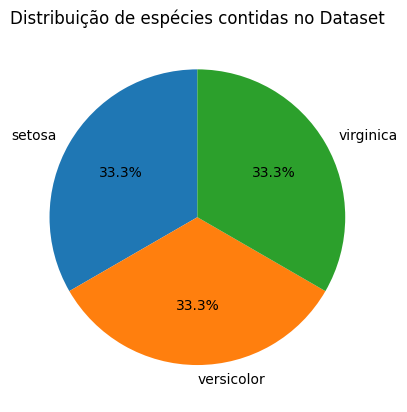

In [ ]:
species_num = df['species'].value_counts()

plt.pie(species_num, labels=species_num.index, autopct='%1.1f%%', startangle = 90)
plt.title('Distribuição de espécies contidas no Dataset')
plt.show()

Com esse gráfico bem simples podemos concluir que esse conjunto de dados tem uma distribuição igual de cada espécie

Plotando um gráfico mais complexo

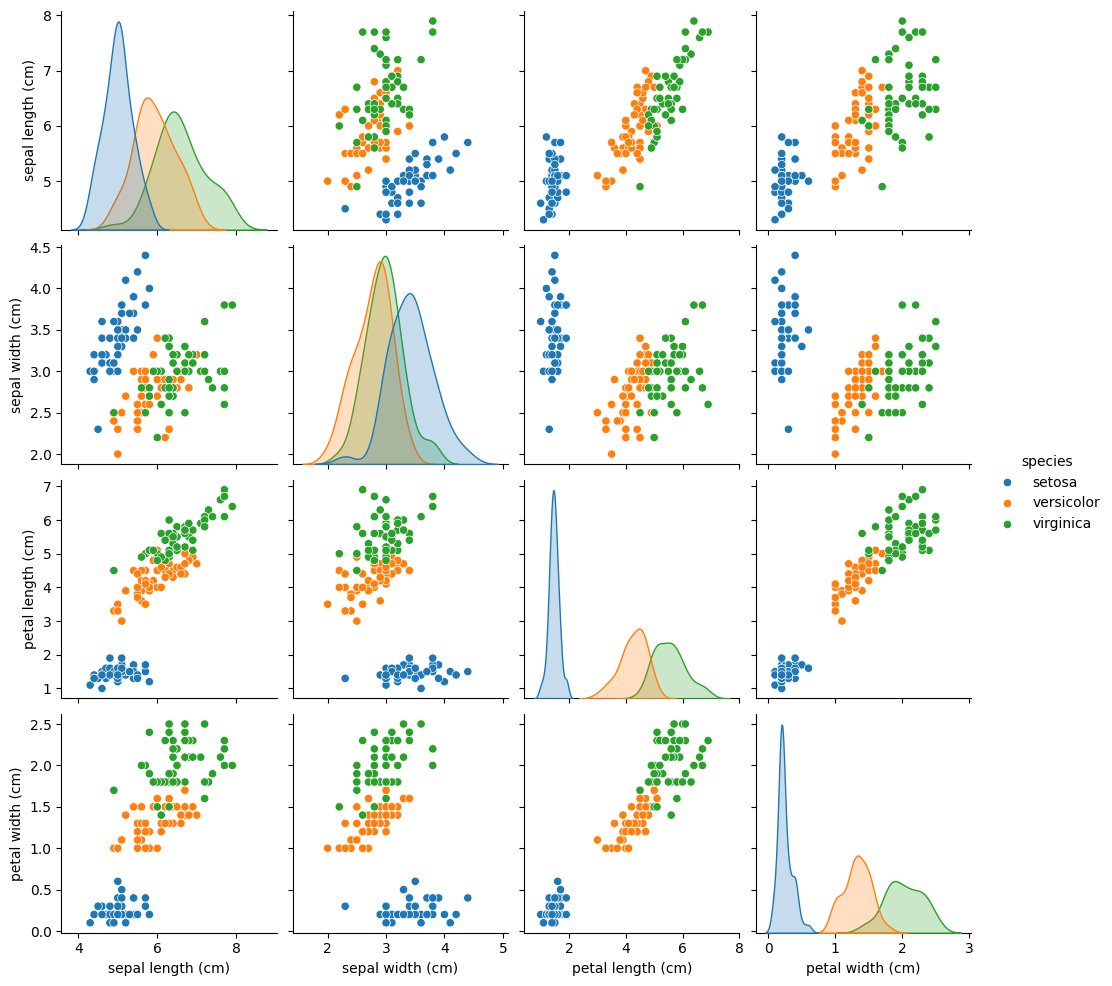

In [ ]:
sns.pairplot(df, hue='species')
plt.show()

Esse gráfico pode parecer assustador, mas acompanhe agora e ele ficará mais simples de entender.

Note que na verdade estamos lidando com uma **matriz** de gráficos, onde nas linhas e colunas temos as variáveis da nossa base e as diferentes cores são para diferenciar as três espécies de flores. Na diagonal principal, temos a **distribuição** de cada variável para cada uma das espécies, enquanto nas demais posições da matriz temos um gráfico de dispersão onde cada ponto colorido representa uma amostra.

Analisando o gráfico, que conclusões podemos tomar?

Ex: As flores da espécie setosa possuem, em média, uma largura menor de sépala. É possível deduzir isso pelo gráfico na posição (1,1)

#Introdução às funções de análise do Pandas

Para começar a análise exploratória, é preciso, primeiro, entender as funções básicas de análise do Pandas

##Funções de visualização

Para começar o processo de análise, utilizaremos um dataset inventado representando uma turma de alguma matéria de exatas da UFRN

[O CSV utilizado está disponível nesse link](https://drive.google.com/file/d/1aFbXjx_b_u6YB_ivbryqoT9HogOX0114/view?usp=drive_link)

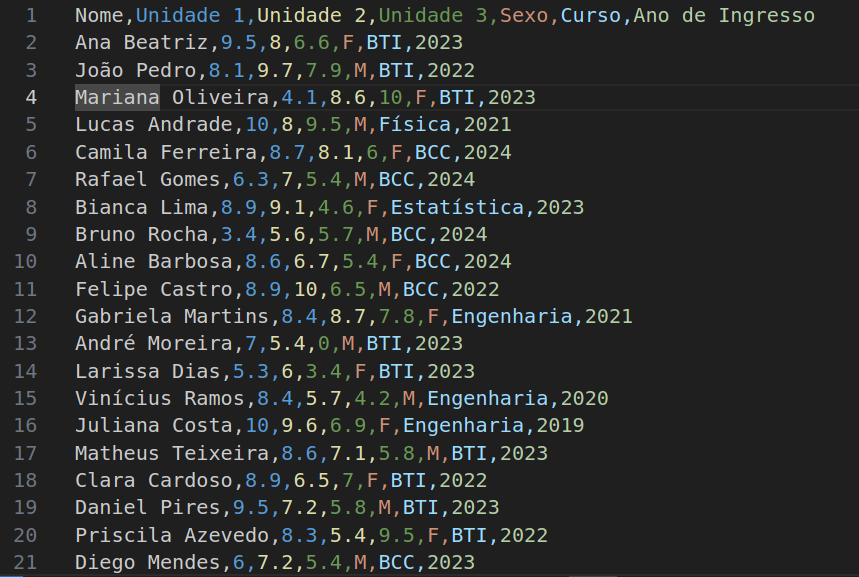

Lembrando que CSV significa Comma Separated values (Valores separados por vírgulas em português). Eles vem nesse formato específico, mostrando as colunas de informações na primeira linha seguido pelos dados nas linhas subsequentes

Alguns CSVs podem vir separados por outros caracteres além da vírgula (Ex: os dados abertos da UFRN são separados por ponto e vírgula ';').

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Turma_X.csv', sep=',') #Aqui importamos o csv Turma_X.csv para usar como dataframe

Para especificar o separador, se passa o argumento sep para a função read_csv. Por padrão ela usa vírgula como separador

###shape

Mostra as proporções do dataset

In [ ]:
df.shape

(20, 7)

O nosso dataset possui 20 linhas de informações separadas em 7 colunas, como pode ser visto no CSV

###head()

Exibe as primeiras linhas do dataframe

In [ ]:
df.head(5)

,Nome,Unidade 1,Unidade 2,Unidade 3,Sexo,Curso,Ano de Ingresso
0,Ana Beatriz,9.5,8.0,6.6,F,BTI,2023
1,João Pedro,8.1,9.7,7.9,M,BTI,2022
2,Mariana Oliveira,4.1,8.6,10.0,F,BTI,2023
3,Lucas Andrade,10.0,8.0,9.5,M,Física,2021
4,Camila Ferreira,8.7,8.1,6.0,F,BCC,2024


O método head exibe as informações do dataframe em formato de tabela, facilitando a leitura comparado a ler o CSV por meio de um editor de texto

O método aceita como argumento a quantidade de linhas que você quer ler do dataset, nesse caso estamos lendo as 5 primeiras linhas.


###info()

Exibe informações básicas sobre as colunas do dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nome             20 non-null     object 
 1   Unidade 1        20 non-null     float64
 2   Unidade 2        20 non-null     float64
 3   Unidade 3        20 non-null     float64
 4   Sexo             20 non-null     object 
 5   Curso            20 non-null     object 
 6   Ano de Ingresso  20 non-null     int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 1.2+ KB


O método mostra o nome de todas colunas listadas e o conteúdo de cada coluna

Nesse exemplo a coluna 'Unidade 1' possui 20 elementos não nulos, ou seja, todas linhas estão preenchidas com algum valor, e o tipo de dado é float. Com essa informação, sabemos que é possível fazer operações matemáticas nessa coluna, como veremos mais adiante com as funções mean(), std(), describe(), etc.

###describe()

Exibe informações numéricas uteis sobre o Dataframe

In [ ]:
df.describe()

,Unidade 1,Unidade 2,Unidade 3,Ano de Ingresso
count,20.00000,20.000000,20.000000,20.000000
mean,7.84500,7.480000,6.170000,2022.450000
std,1.88665,1.481678,2.275753,1.356272
min,3.40000,5.400000,0.000000,2019.000000
25%,6.82500,6.375000,5.400000,2022.000000
50%,8.50000,7.200000,5.900000,2023.000000
75%,8.90000,8.625000,7.200000,2023.000000
max,10.00000,10.000000,10.000000,2024.000000


Como se pode ver, esse método só exibe as colunas com informações númericas, excluindo as do tipo object.

Ele exibe o maior e menor (min, max) valor da coluna, a média (avg), o desvio padrão (std) e os valores nos percentis 25, 50 e 75 ([Explicação sobre o que é percentil](https://didatica.tech/o-que-e-percentil-quartil-e-como-calcular/))

###value_counts()

Mostra uma tabela com a quantidade de repetições de valores diferentes

In [ ]:
print('Saída para a coluna curso')
display(df['Curso'].value_counts())
print('Saída para a coluna nome')
display(df['Nome'].value_counts())
print('Saída sem escolher coluna')
display(df.value_counts())

Saída para a coluna curso


,count
Curso,
BTI,9
BCC,6
Engenharia,3
Física,1
Estatística,1


Saída para a coluna nome


,count
Nome,
Ana Beatriz,1
João Pedro,1
Mariana Oliveira,1
Lucas Andrade,1
Camila Ferreira,1
Rafael Gomes,1
Bianca Lima,1
Bruno Rocha,1
Aline Barbosa,1


Saída sem escolher coluna


,,,,,,,count
Nome,Unidade 1,Unidade 2,Unidade 3,Sexo,Curso,Ano de Ingresso,
Aline Barbosa,8.6,6.7,5.4,F,BCC,2024,1
Ana Beatriz,9.5,8.0,6.6,F,BTI,2023,1
André Moreira,7.0,5.4,0.0,M,BTI,2023,1
Bianca Lima,8.9,9.1,4.6,F,Estatística,2023,1
Bruno Rocha,3.4,5.6,5.7,M,BCC,2024,1
Camila Ferreira,8.7,8.1,6.0,F,BCC,2024,1
Clara Cardoso,8.9,6.5,7.0,F,BTI,2022,1
Daniel Pires,9.5,7.2,5.8,M,BTI,2023,1
Diego Mendes,6.0,7.2,5.4,M,BCC,2023,1


Para usar esse método eficientemente, escolhe-se uma coluna que possua dados que se repetem. Nesse caso escolhemos a coluna curso, pois os cursos se repetem nesse conjunto.

Se escolhessemos a coluna nome por exemplo, a informação não seria util, pois cada nome ocorreria exatamente uma vez no dataset

##Operações com linhas e colunas

O pandas te permite criar dataframes derivados de informações específicas do dataframe original

Exemplos a seguir

###Filtrando por colunas

###Quais são os alunos que ingressaram em 2023?

Para extrair essa informação, criaremos um novo dataframe com a coluna 'Ano de Ingresso' restrita a ter o valor 2023

In [ ]:
df_alunos2023 = df[df['Ano de Ingresso'] == 2023] #entende-se essa sintaxe como:
#df_alunos2023 recebe todos elementos de df que possuem 2023 na coluna 'Ano de Ingresso'
df_alunos2023

,Nome,Unidade 1,Unidade 2,Unidade 3,Sexo,Curso,Ano de Ingresso
0,Ana Beatriz,9.5,8.0,6.6,F,BTI,2023
2,Mariana Oliveira,4.1,8.6,10.0,F,BTI,2023
6,Bianca Lima,8.9,9.1,4.6,F,Estatística,2023
11,André Moreira,7.0,5.4,0.0,M,BTI,2023
12,Larissa Dias,5.3,6.0,3.4,F,BTI,2023
15,Matheus Teixeira,8.6,7.1,5.8,M,BTI,2023
17,Daniel Pires,9.5,7.2,5.8,M,BTI,2023
19,Diego Mendes,6.0,7.2,5.4,M,BCC,2023


E qual é a média das notas desse grupo específico?

Para isso utilizaremos o método mean()

In [ ]:
df_media_alunos2023 = df_alunos2023[['Unidade 1', 'Unidade 2', 'Unidade 3']]
df_media_alunos2023.mean()

,0
Unidade 1,7.3625
Unidade 2,7.3250
Unidade 3,5.2000


mean() só funciona nas colunas numéricas, por isso restringimos para calcular as médias das colunas das unidades

###Agrupando por características

###Como pegar a nota média de cada curso

Para agrupar por uma característica específica presente nas linhas, como o ano de ingresso ou o curso, utilizaremos o método groupby.

In [ ]:
df_cursos = df.groupby('Curso')
df_cursos_media = df_cursos[['Unidade 1', 'Unidade 2', 'Unidade 3']].mean()
df_cursos_media

,Unidade 1,Unidade 2,Unidade 3
Curso,,,
BCC,6.983333,7.433333,5.733333
BTI,7.700000,7.100000,6.222222
Engenharia,8.933333,8.000000,6.300000
Estatística,8.900000,9.100000,4.600000
Física,10.000000,8.000000,9.500000


Para pegar a média das linhas, usa-se o método mean() passando como argumento axis = 1

In [ ]:
df_cursos_media.mean(axis=1)

,0
Curso,
BCC,6.716667
BTI,7.007407
Engenharia,7.744444
Estatística,7.533333
Física,9.166667


###Método .aggregate()

É um método robusto, que serve para rapidamente extrair informações do dataset como a média, mediana, desvio padrão, etc.

In [ ]:
df_ano_ingresso = df.groupby('Ano de Ingresso')
df_ano_ingresso[['Unidade 1']].aggregate(['count','min', 'max','std', 'mean', 'var'])

Unidade 1                                         
                    count   min   max       std     mean       var
Ano de Ingresso                                                   
2019                    1  10.0  10.0       NaN  10.0000       NaN
2020                    1   8.4   8.4       NaN   8.4000       NaN
2021                    2   8.4  10.0  1.131371   9.2000  1.280000
2022                    4   8.1   8.9  0.412311   8.5500  0.170000
2023                    8   4.1   9.5  2.067391   7.3625  4.274107
2024                    4   3.4   8.7  2.493324   6.7500  6.216667

Todos esses argumentos colocados no método aggregate dentro do array são outros métodos que podem ser chamados da mesma forma que foi feita para o método mean.

var e std são a variância e desvio padrão respectivamente.

O valor de std e var estão na forma NaN em 2019 e 2020, pois naqueles anos só há um discente.

# Prática e Exercícios


Agora, vamos por em prática o que foi abordado através de alguns exercícios. A prática é fundamental para acostumar a mente aos novos conceitos aprendidos.

Vamos utilizar o dataset dos estudantes de uma universidade que foi trabalhado no dia anterior

[Link do dataset](https://drive.google.com/file/d/1kq0WDnpWiyOsQuMfYxAU7fypxsMUc_ey/view?usp=sharing)

In [ ]:
# Importando a biblioteca
import pandas as pd

# Lendo o arquivo com os dados
df = pd.read_csv('dataset_exemplos_limpo.csv')

## Exercícios de Descrição e Entendimento dos dados

O primeiro passo ao explorar um dataset novo é entender o que ele está falando, como ele apresenta seus dados e como esses dados estão dispostos. Essa parte é essencial para gerar insights futuros (afinal, como você vai ter alguma ideía de como explorar os dados se nem entende o que eles dizem pra começo de conversa).

**Exercícios:**
1. Mostre as **5 primeiras linhas** do dataset.
2. Obtenha informações **estruturais**: número de linhas, colunas e tipos de dados.
3. Gere estatísticas **descritivas** das colunas numéricas (`CRA`, `Taxa_Mensalidade`, `Horas_Atividade_Extra`).
4. Mostre apenas as colunas **`ID_Aluno`**, **`Nome`** e **`CRA`**.
5. Quantos **cursos diferentes** existem no dataset? Quais são eles?
6. Qual a **proporção de alunos por curso**?



## Exercícios de Filtragem e Manipulação dos dados

Bases de dados podem ser muito complexas e difíceis de se visualizar por muitas vezes, para extrair informações relevantes e específicas é importante saber como manipular o dataset ao nosso favor, de forma que ele mostre apenas o que nos é de interessente. Fazemos isso principalmente através de filtros.

**Exercícios:**
7. Filtre os alunos com `CRA` maior que 8.
8. Filtre apenas os alunos que **possuem bolsa**.
9. Filtre os alunos do curso **Psicologia** com `CRA` acima de 7.5.
10. Filtre os alunos cuja **mensalidade é maior que 2500 reais**.



## Exercícios de Agrupamento de dados e funções de Agregação

Para obter informações relacionais de dados distintos, a principal ferramenta que utilizamos é o agrupamento de dados, e para extrair informações mais úteis, podemos utilizar funções de agregação.

**Exercícios:**
11. Agrupe os dados por `Curso` e calcule a **média do CRA** por curso.
12. Qual a média de horas de atividade extra por período atual? (agrupado por `Periodo_Atual`).
13. Quantos alunos há por `Ano_Ingresso`?


# Introdução à biblioteca Matplotlib

In [ ]:
# Importando a biblioteca
import matplotlib.pyplot as plt
# Importando bibliotecas auxiliares para os exemplos
import numpy as np
import pandas as pd

O matplotlib é uma biblioteca de visualização de dados em Python, muito utilizada para gerar gráficos estáticos, interativos ou animados. A interface mais comum é o pyplot.

Por que a matplotlib?

*   Integração com Numpy e Pandas
*   Altamente personalizável
*   Útil para análises exploratórias e apresentações


Funções principais


*   plot()

*   show()



**Plot()**
A função plot() é usada para criar gráficos de linha, que mostram a relação entre dois conjuntos de dados — normalmente, um eixo X (horizontal) e um eixo Y (vertical).

Ela é usada na forma plt.plot(x, y)

O primeiro argumento (x) representa os valores do eixo horizontal.

O segundo argumento (y) representa os valores do eixo vertical.

Por padrão, plot() conecta os pontos com uma linha contínua.

**Show()**

Após criar um gráfico com plot(), ele ainda não será exibido na tela. Para visualizar o gráfico, usamos a função show():

plt.show()

Essa função abre uma janela interativa com o gráfico ou exibe o gráfico inline (diretamente no notebook). Enquanto plot() cria o gráfico internamente, show() é o comando que efetivamente o desenha e mostra ao usuário.

Sumarizando como os Gráficos são Plotados

    A função plt.plot() é usada para criar gráficos de linha. Ela recebe como parâmetros duas listas de dados, uma
    representando o eixo X e a outra o eixo Y.
    Após a definição do gráfico, usamos plt.show()
    para exibir.
    Os elementos básicos:
    título (plt.title),
    rótulos dos eixos (plt.xlabel, plt.ylabel),
    e grade (plt.grid)[responsável pela malha quadriculada na imagem].

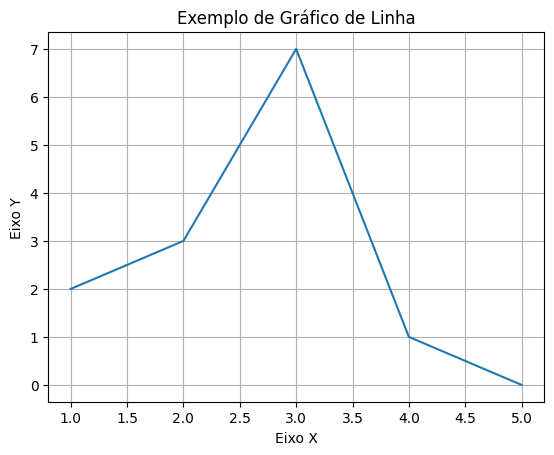

In [ ]:
# Exemplo básico: gráfico de linha
x = [1, 2, 3, 4, 5]
y = [2, 3, 7, 1, 0]

plt.plot(x, y)
plt.title("Exemplo de Gráfico de Linha")
plt.xlabel("Eixo X")
plt.ylabel("Eixo Y")
plt.grid(True)
plt.show()


## Tipos de Gráficos

Gráfico de barras

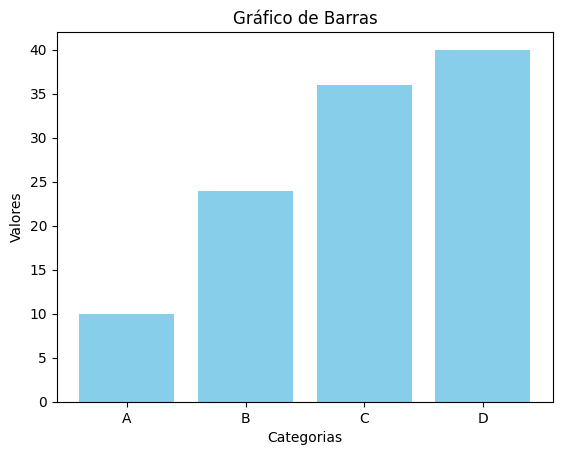

In [ ]:
categorias = ['A', 'B', 'C', 'D']
valores = [10, 24, 36, 40]

plt.bar(categorias, valores, color='skyblue')
plt.title("Gráfico de Barras")
plt.xlabel("Categorias")
plt.ylabel("Valores")
plt.show()


Histograma

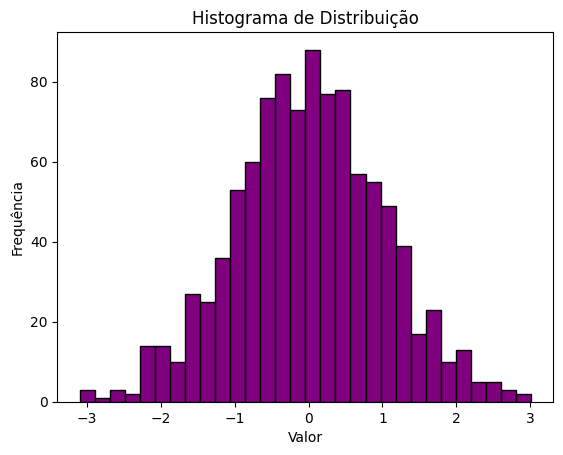

In [ ]:
dados = np.random.normal(0, 1, 1000)  # distribuição normal

plt.hist(dados, bins=30, color='purple', edgecolor='black')
plt.title("Histograma de Distribuição")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()


BoxPlot

/tmp/ipython-input-13-412830360.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dados1, dados2, dados3], labels=['Grupo 1', 'Grupo 2', 'Grupo 3'])


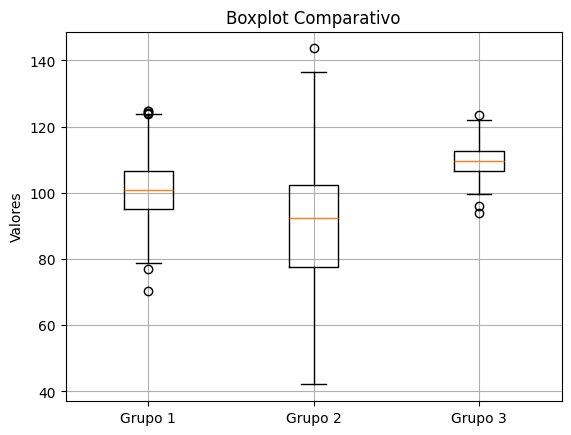

In [ ]:
np.random.seed(10)
dados1 = np.random.normal(100, 10, 200)
dados2 = np.random.normal(90, 20, 200)
dados3 = np.random.normal(110, 5, 200)

plt.boxplot([dados1, dados2, dados3], labels=['Grupo 1', 'Grupo 2', 'Grupo 3'])
plt.title("Boxplot Comparativo")
plt.ylabel("Valores")
plt.grid(True)
plt.show()


Gráfico de Linhas

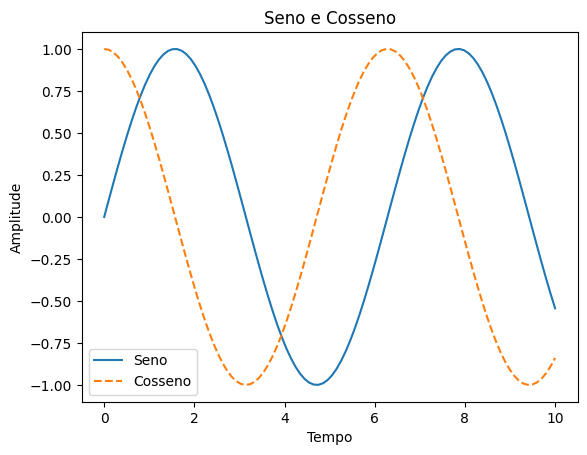

In [ ]:
t = np.linspace(0, 10, 100)
seno = np.sin(t)
cosseno = np.cos(t)

plt.plot(t, seno, label='Seno') # Perceba a inserção de multiplas linhas(2) para o gráfico
plt.plot(t, cosseno, label='Cosseno', linestyle='--')
plt.title("Seno e Cosseno")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


Matriz de Correlação (utilizando também a biblioteca Seaborn)

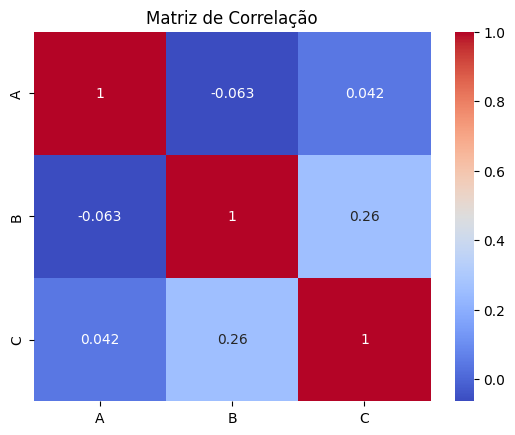

In [ ]:
import seaborn as sns

# Criando um DataFrame de exemplo
df = pd.DataFrame({
    'A': np.random.rand(100),
    'B': np.random.rand(100),
    'C': np.random.rand(100) * 0.5 + np.random.rand(100) * 0.5
})

correlacao = df.corr()

sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()


# Exercícios Matplotlib

##Exercícios de visualização de dados

Agora, utilizando os conhecimentos abordados no curso, vamos aplicar um exercício prático utilizando os dados do csv "dataset_exemplos_limpo.csv" com base na celula abaixo.

Faça graficos para exemplificar as seguintes questões:

a) Como os alunos estão distribuídos em cada curso?

b) Como é distribuída a mensalidade da faculdade de maneira geral?

c) Quais são os valores que variam nas mensalidades para cada curso?

d) Qual foi a progressão da média dos alunos durante os anos?